In [1]:
pip install fredapi python-dotenv pandas statsmodels



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from fredapi import Fred
from dotenv import load_dotenv
import pandas as pd
import os
from functools import reduce

In [3]:
load_dotenv()
FRED_API_KEY = os.getenv("FRED_API_KEY")
fred_auth = fred = Fred(api_key=FRED_API_KEY)

# Point In Time Logic (Predicting on a monthly time unit)

* If your model is **designed to run on the 1st of the month** (e.g., Jan 1st), it has to use whatever the most recently published data is on that exact day.
* When we train our model using historical data, we are not just trying to find historical patterns. We are trying to simulate exactly what the model would have seen if it had been running live on that historical day.

### Example
* When we are training the model, its supposed to predict on a time period of one month (let's say the 31st of each month)
* When it predicts on the 31st of the month you are try to fetch all the data, but for january's unemployment rate, cpi, etc. all of these things aren't available until mid feb
* So actually, you are supposed to use last month's data to do the prediction (e.g. the december data is used for january prediction)

### Metrics
A. The "Hard" Coincident Pillar (PAYEMS, UNRATE, INDPRO)
What they mean: These measure the actual "output" of the economy right now.
- Recession Logic: These are usually the last to break. If your model sees a spike in UNRATE_MoM_diff alongside a drop in PAYEMS_MoM, the recession is likely already happening.

B. The "Expectations" Leading Pillar (UMCSENT, T10Y3M, T10Y2Y)
What they mean: These measure what people think will happen.
- Recession Logic: These are your most powerful features for the "6-month look-ahead." When consumer sentiment (UMCSENT) drops sharply, it predicts a drop in spending 3–6 months later. When the yield curve (T10Y3M) inverts, it means the bond market is "pricing in" a future crash.

C. The "Policy" Pillar (CPIAUCSL, BAA10Y)
What they mean: These measure the cost of money and credit.
- Recession Logic: High CPI forces the Fed to keep rates high. Wide BAA10Y spreads mean the private market is getting "scared" to lend. Together, these create the "liquidity squeeze" that usually triggers the recession.

In [4]:
recession_data = pd.DataFrame(fred_auth.get_series("USREC")).reset_index().rename(columns={"index": "aligned_date", 0: "recession"})
recession_data = recession_data[recession_data['aligned_date'] >= pd.to_datetime('2001-01-01')]

# list of metrics to pull from FRED: consumer price index, payroll employment, unemployment rate, industrial production, 10 year minus 3 month treasury yield
# 'realtime_start' = The Publication Day / Knowledge Date
# 'date' = The Observation Month
# 'value' = The CPI value at that time

monthly_revised = ["CPIAUCSL", "PAYEMS", "UNRATE", "INDPRO","UMCSENT"]
daily_market = ["T10Y3M", "T10Y2Y", "BAA10Y"]

economic_data = {}

economic_data["recession"] = recession_data

for metric in monthly_revised:
    print(f"Pulling first-release data for {metric}...")
    df = fred_auth.get_series_all_releases(metric, realtime_start="2001-01-01")
    df = df[df['date'] >= pd.to_datetime('2001-01-01')]
    # The reason for first releases is because we are assessing the data as it was available at the time of release
    # because this often guides future economic decisions and market reactions.
    # we also only keep the 'realtime_start' and 'value' columns, as we our focusing on the publication day
    first_release_df = df.groupby("date").head(1)
    first_release_df["aligned_date"] = pd.to_datetime(first_release_df["realtime_start"]) + pd.offsets.MonthBegin(1)
    first_release_df = first_release_df.sort_values(by=["realtime_start", "date"])
    first_release_df = first_release_df.drop_duplicates(subset=["aligned_date"], keep="last")
    first_release_df.rename(columns={"realtime_start": "publication_date",'date': 'observation_month','value': f"{metric}"}, inplace=True)
    economic_data[metric] = first_release_df


for metric in daily_market:
    print(f"Pulling market data for {metric}...")
    economic_data[metric] = fred_auth.get_series(metric, observation_start="2001-01-01")
    # resample for last day of the month
    # convert to period and back to timestamp to get the last day of the month, 
    # reset index and rename columns
    economic_data[metric] = (
        pd.DataFrame(economic_data[metric])
        .resample("ME")
        .last()
        .reset_index()
        .rename(columns={"index": "date", 0: f"{metric}"})
    )
    economic_data[metric]["aligned_date"] = economic_data[metric]["date"] + pd.offsets.MonthBegin(1)

Pulling first-release data for CPIAUCSL...
Pulling first-release data for PAYEMS...
Pulling first-release data for UNRATE...
Pulling first-release data for INDPRO...
Pulling first-release data for UMCSENT...
Pulling market data for T10Y3M...
Pulling market data for T10Y2Y...
Pulling market data for BAA10Y...


- The model now assumes we are running on the [first of each month]
- We pull the most 'recent' available data for cpi/unemployment date, which is the data published on the month before - which was observing for the month before that
- We then also pull the last known yield curve data excluding the day we are running it
- Which is why we have aligned dates for all the data sources which is offset to the first day of the month after the data was published

In [5]:
all_dfs_cleaned = [df[['aligned_date', metric]] for metric, df in economic_data.items()]
df_final = reduce(lambda left, right: pd.merge(left, right, on='aligned_date', how='outer'), all_dfs_cleaned).sort_values('aligned_date')
df_final.dropna(inplace=True)
df_final.tail(20)

,aligned_date,recession,CPIAUCSL,PAYEMS,UNRATE,INDPRO,UMCSENT,T10Y3M,T10Y2Y,BAA10Y
281,2024-06-01,0.0,313.207,158286.0,3.9,102.7623,69.1,-0.95,-0.38,1.46
282,2024-07-01,0.0,313.225,158543.0,4.0,103.3284,68.2,-1.12,-0.35,1.55
283,2024-08-01,0.0,313.049,158638.0,4.1,103.9941,66.4,-1.32,-0.20,1.68
284,2024-09-01,0.0,313.534,158723.0,4.3,102.8887,67.9,-1.30,0.00,1.69
285,2024-10-01,0.0,314.121,158779.0,4.2,103.1389,70.1,-0.92,0.15,1.63
286,2024-11-01,0.0,314.686,159105.0,4.1,102.6418,70.5,-0.36,0.12,1.46
287,2024-12-01,0.0,315.454,159005.0,4.1,102.2805,71.8,-0.40,0.05,1.44
288,2025-01-01,0.0,316.441,159288.0,4.2,101.9621,74.0,0.21,0.33,1.42
289,2025-02-01,0.0,317.685,159536.0,4.1,103.1942,71.7,0.27,0.36,1.45
290,2025-03-01,0.0,319.086,159069.0,4.0,103.511,64.7,-0.08,0.25,1.57


In [6]:
# target variable engineering - for month t, our target y_t is 1 if there is a recession in any of the subsequent 6 months
# .rolling() looks backward in time. For months 0,1,2,3,4,5,6,7, recession starts in month 5
# .rolling(window=6, min_periods=1) -> goes to every single row and draws a box around the current row and the 5 previous rows (a total window of 6).
# the window includes Months [1, 2, 3, 4, 5, 6].
# .max() Pandas looks inside that 6-month box and finds the highest number.
# For the box ending at Month 6 (which contains [0, 0, 0, 0, 1, 1]), the .max() is 1.
# .shift(-6) a negative shift moves data up the DataFrame -> We take that .max() result at Month 6, and we shift it up by 6 rows and lands exactly on Month 0.

df_final['target'] = df_final['recession'].rolling(window=6, min_periods=1).max().shift(-6)

# For trending cumulative data (CPIAUCSL, PAYEMS, INDPRO): 
# Calculate the Month-over-Month (MoM) percentage change and the Year-over-Year (YoY) percentage change (which is a 12-month lookback).
for metric in ["CPIAUCSL", "PAYEMS", "INDPRO","UMCSENT"]:
    df_final[f"{metric}_MoM"] = df_final[metric].pct_change()
    df_final[f"{metric}_YoY"] = df_final[metric].pct_change(periods=12)
    
# For rate-based data (UNRATE, T10Y3M): These are already percentages. 
# Instead of a percentage of a percentage, it is standard practice to just calculate the absolute 
# difference from the previous month (MoM Difference) and from 12 months ago (YoY Difference).
for metric in ["UNRATE", "T10Y3M", "T10Y2Y", "BAA10Y"]:
    df_final[f"{metric}_MoM_diff"] = df_final[metric].diff()
    df_final[f"{metric}_YoY_diff"] = df_final[metric].diff(periods=12)

In [7]:
df_final.head(20)

,aligned_date,recession,CPIAUCSL,PAYEMS,UNRATE,INDPRO,UMCSENT,T10Y3M,T10Y2Y,BAA10Y,...,UMCSENT_MoM,UMCSENT_YoY,UNRATE_MoM_diff,UNRATE_YoY_diff,T10Y3M_MoM_diff,T10Y3M_YoY_diff,T10Y2Y_MoM_diff,T10Y2Y_YoY_diff,BAA10Y_MoM_diff,BAA10Y_YoY_diff
2,2001-03-01,0.0,175.7,132129.0,4.2,146.997,94.7,0.07,0.51,2.88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2001-04-01,1.0,176.2,132237.0,4.2,146.001,91.5,0.63,0.75,3.04,...,-0.033791,NaN,0.0,NaN,0.56,NaN,0.24,NaN,0.16,NaN
4,2001-05-01,1.0,176.3,132221.0,4.3,146.466,88.4,1.40,1.05,2.73,...,-0.03388,NaN,0.1,NaN,0.77,NaN,0.30,NaN,-0.31,NaN
5,2001-06-01,1.0,176.8,132027.0,4.5,144.866,92.0,1.80,1.21,2.65,...,0.040724,NaN,0.2,NaN,0.40,NaN,0.16,NaN,-0.08,NaN
6,2001-07-01,1.0,177.5,132453.0,4.4,143.12,92.6,1.77,1.17,2.65,...,0.006522,NaN,-0.1,NaN,-0.03,NaN,-0.04,NaN,0.00,NaN
7,2001-08-01,1.0,177.9,132383.0,4.5,142.501,92.4,1.53,1.28,2.78,...,-0.00216,NaN,0.1,NaN,-0.24,NaN,0.11,NaN,0.13,NaN
8,2001-09-01,1.0,177.4,132395.0,4.5,142.849,91.5,1.48,1.21,2.90,...,-0.00974,NaN,0.0,NaN,-0.05,NaN,-0.07,NaN,0.12,NaN
9,2001-10-01,1.0,177.5,132331.0,4.9,141.499,81.8,2.20,1.74,3.42,...,-0.106011,NaN,0.4,NaN,0.72,NaN,0.53,NaN,0.52,NaN
10,2001-11-01,1.0,178.2,132166.0,4.9,140.3,82.7,2.25,1.86,3.38,...,0.011002,NaN,0.0,NaN,0.05,NaN,0.12,NaN,-0.04,NaN
11,2001-12-01,0.0,177.6,131767.0,5.4,139.307,83.9,3.00,1.94,3.10,...,0.01451,NaN,0.5,NaN,0.75,NaN,0.08,NaN,-0.28,NaN


# Augmented Dickey-Fuller (ADF) 
It is a test for stationarity - a time series is stationary if its core statistical properties—specifically its mean and variance—do not change over time.

- Imagine a pendulum swinging back and forth around a fixed center point. That is stationary.
- Now imagine a dog wandering freely through a park, wandering further and further away. That is a "random walk," which is non-stationary.

Macroeconomic absolute numbers (like total CPI or the S&P 500 price) are non-stationary. They drift upward over decades. If you feed them into a machine learning model, the model essentially learns "higher number = closer to the year 2024," which is completely useless for predicting the future.

**ADF test is fundamentally checking for something called a "Unit Root." If a time series has a unit root, it is a random walk (non-stationary).**

Let's look at a basic Autoregressive, or AR(1), model, which states that today's value ($y_t$) depends on yesterday's value ($y_{t-1}$) plus some random noise ($\epsilon_t$):$$y_t = \rho y_{t-1} + \epsilon_t$$

If $\rho = 1$, the series has a "unit root." This means today's value is exactly yesterday's value plus random noise. It will drift infinitely.

If you subtract $y_{t-1}$ from both sides to look at the change ($\Delta y_t$):$$\Delta y_t = (\rho - 1)y_{t-1} + \epsilon_t$$Let's define $\gamma = \rho - 1$. The equation becomes:$$\Delta y_t = \gamma y_{t-1} + \epsilon_t$$

Test hypotheses:
- The Null Hypothesis ($H_0$): $\gamma = 0$ (which means $\rho = 1$). The series has a unit root and is non-stationary.
- The Alternative Hypothesis ($H_1$): $\gamma < 0$. The series does not have a unit root and is stationary.


In [8]:
# The Augmented Dickey-Fuller test is a formal statistical test where the null hypothesis is that the time series is non-stationary.
# If the p-value is < 0.05, you reject the null hypothesis and can confidently tell your evaluators: "My features are stationary."
from statsmodels.tsa.stattools import adfuller
for column in df_final.columns:
    if column not in ['aligned_date', 'recession',"CPIAUCSL", "PAYEMS", "INDPRO", "UNRATE", "T10Y3M","T10Y2Y", "BAA10Y","UMCSENT"]:
        result = adfuller(df_final[column].dropna())
        print(f"p-value for {column}: {result[1]}")
        print (f"Is {column} stationary? {'Yes' if result[1] < 0.05 else 'No'}")
        print("------")

p-value for target: 0.0007607493348909145
Is target stationary? Yes
------
p-value for CPIAUCSL_MoM: 1.171938695539868e-11
Is CPIAUCSL_MoM stationary? Yes
------
p-value for CPIAUCSL_YoY: 0.07077934380665087
Is CPIAUCSL_YoY stationary? No
------
p-value for PAYEMS_MoM: 1.8734402485482962e-25
Is PAYEMS_MoM stationary? Yes
------
p-value for PAYEMS_YoY: 0.015935275504324897
Is PAYEMS_YoY stationary? Yes
------
p-value for INDPRO_MoM: 1.5234776176676845e-27
Is INDPRO_MoM stationary? Yes
------
p-value for INDPRO_YoY: 0.0013482562068624108
Is INDPRO_YoY stationary? Yes
------
p-value for UMCSENT_MoM: 2.5620026180070052e-27
Is UMCSENT_MoM stationary? Yes
------
p-value for UMCSENT_YoY: 0.00035893622315247433
Is UMCSENT_YoY stationary? Yes
------
p-value for UNRATE_MoM_diff: 1.330570417800003e-17
Is UNRATE_MoM_diff stationary? Yes
------
p-value for UNRATE_YoY_diff: 0.00721417763386609
Is UNRATE_YoY_diff stationary? Yes
------
p-value for T10Y3M_MoM_diff: 9.969489907605956e-29
Is T10Y3M_MoM_

In [9]:
# addressing the non_stationary CPIAUCSL_YOY
# YoY CPI is borderline non-stationary is that inflation tends to "trend" in long waves (e.g., the high-inflation era of 2021–2023).
# Using the Year-over-Year Change in the Inflation Rate. 
# This tells the model if inflation is accelerating or decelerating, rather than just telling it the absolute level.

df_final["CPIAUCSL_YoY"] = df_final["CPIAUCSL_YoY"].diff()
df_final.head(20)
for column in df_final.columns:
    if column not in ['aligned_date', 'recession',"CPIAUCSL", "PAYEMS", "INDPRO", "UNRATE", "T10Y3M","T10Y2Y", "BAA10Y","UMCSENT"]:
        result = adfuller(df_final[column].dropna())
        print(f"p-value for {column}: {result[1]}")
        print (f"Is {column} stationary? {'Yes' if result[1] < 0.05 else 'No'}")
        print("------")

p-value for target: 0.0007607493348909145
Is target stationary? Yes
------
p-value for CPIAUCSL_MoM: 1.171938695539868e-11
Is CPIAUCSL_MoM stationary? Yes
------
p-value for CPIAUCSL_YoY: 1.8857024341215427e-05
Is CPIAUCSL_YoY stationary? Yes
------
p-value for PAYEMS_MoM: 1.8734402485482962e-25
Is PAYEMS_MoM stationary? Yes
------
p-value for PAYEMS_YoY: 0.015935275504324897
Is PAYEMS_YoY stationary? Yes
------
p-value for INDPRO_MoM: 1.5234776176676845e-27
Is INDPRO_MoM stationary? Yes
------
p-value for INDPRO_YoY: 0.0013482562068624108
Is INDPRO_YoY stationary? Yes
------
p-value for UMCSENT_MoM: 2.5620026180070052e-27
Is UMCSENT_MoM stationary? Yes
------
p-value for UMCSENT_YoY: 0.00035893622315247433
Is UMCSENT_YoY stationary? Yes
------
p-value for UNRATE_MoM_diff: 1.330570417800003e-17
Is UNRATE_MoM_diff stationary? Yes
------
p-value for UNRATE_YoY_diff: 0.00721417763386609
Is UNRATE_YoY_diff stationary? Yes
------
p-value for T10Y3M_MoM_diff: 9.969489907605956e-29
Is T10Y3M_

In [10]:
pip install scikit-learn xgboost 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


- Precision the proportion of all classifications that were correct, whether positive or negative. Written as a formula: $$\text{Correct Classifications}/ \text{Total Classifications}$$

$$(\text{TP + TN})/(\text{TP+TN+FP+FN})$$

- Recall the proportion of all actual positives that were classified correctly as positives. Written as a formula: $$\text{Correctly Classified Actual Positives}/ \text{All Actual Positives}$$

$$(\text{TP})/(\text{TP+FN})$$


In [11]:
df_training_data = df_final.drop(columns=['recession',"CPIAUCSL", "PAYEMS", "INDPRO", "UNRATE", "T10Y3M", "T10Y2Y", "BAA10Y","UMCSENT"]).dropna()
df_training_data.head(20)

,aligned_date,target,CPIAUCSL_MoM,CPIAUCSL_YoY,PAYEMS_MoM,PAYEMS_YoY,INDPRO_MoM,INDPRO_YoY,UMCSENT_MoM,UMCSENT_YoY,UNRATE_MoM_diff,UNRATE_YoY_diff,T10Y3M_MoM_diff,T10Y3M_YoY_diff,T10Y2Y_MoM_diff,T10Y2Y_YoY_diff,BAA10Y_MoM_diff,BAA10Y_YoY_diff
16,2002-05-01,0.0,0.003371,0.00053,0.000053,-0.007328,0.008799,-0.049013,-0.028213,0.016393,0.2,1.5,-0.29,2.71,0.17,1.12,0.03,-0.20
17,2002-06-01,0.0,0.005039,0.00453,-0.000289,-0.007495,0.002204,-0.049943,0.041935,0.096154,0.3,1.7,0.00,1.94,-0.01,0.81,0.14,0.25
18,2002-07-01,0.0,0.0,-0.002879,-0.003673,-0.009687,0.001315,-0.038187,-0.04644,0.004348,-0.2,1.3,-0.18,1.36,0.10,0.75,0.15,0.48
19,2002-08-01,0.0,0.001114,-0.002877,-0.000061,-0.012933,0.008871,-0.017817,-0.046537,-0.048596,0.1,1.5,-0.36,1.03,0.32,1.11,0.12,0.60
20,2002-09-01,0.0,0.001113,-0.001152,0.00026,-0.012154,0.000832,-0.01273,-0.005675,-0.051948,0.0,1.4,-0.35,0.92,-0.28,0.72,0.07,0.54
21,2002-10-01,0.0,0.003335,0.006232,0.00052,-0.01173,-0.001031,-0.01615,-0.017123,-0.059016,-0.2,1.2,-0.39,0.58,-0.09,0.70,0.44,0.86
22,2002-11-01,0.0,0.001662,0.001117,0.000092,-0.011161,-0.000349,-0.00711,-0.063879,-0.01467,-0.1,0.7,0.43,0.29,0.34,0.51,0.06,0.40
23,2002-12-01,0.0,0.002765,-0.001195,0.000313,-0.009617,-0.008541,-0.007177,0.044665,0.018138,0.1,0.8,0.51,0.75,-0.11,0.28,-0.44,0.00
24,2003-01-01,0.0,0.001103,0.004563,-0.000153,-0.00677,-0.204583,-0.204663,0.029691,0.033373,0.3,0.6,-0.39,-0.39,0.08,0.28,0.10,0.38
25,2003-02-01,0.0,0.000551,0.000563,-0.001268,-0.005493,-0.001751,-0.193504,-0.049596,-0.072072,0.0,0.3,0.21,-0.51,0.06,0.28,-0.32,0.31


In [12]:
# ~60/40 chronological split
split_idx = int(len(df_training_data) * 0.6)

# start at the beginning and go up to, but do not include, index x."
training_data = df_training_data.iloc[:split_idx]
testing_data = df_training_data.iloc[split_idx:]

training_x = training_data.drop(columns=['target','aligned_date'])
training_y = training_data['target']
testing_x = testing_data.drop(columns=['target','aligned_date'])
testing_y = testing_data['target']

print("Training data:")
print(training_y.value_counts())
print("\nTesting data:")
print(testing_y.value_counts())

Training data:
target
0.0    132
1.0     21
Name: count, dtype: int64

Testing data:
target
0.0    96
1.0     7
Name: count, dtype: int64


In [13]:
testing_data[testing_data['target'] == 1]

,aligned_date,target,CPIAUCSL_MoM,CPIAUCSL_YoY,PAYEMS_MoM,PAYEMS_YoY,INDPRO_MoM,INDPRO_YoY,UMCSENT_MoM,UMCSENT_YoY,UNRATE_MoM_diff,UNRATE_YoY_diff,T10Y3M_MoM_diff,T10Y3M_YoY_diff,T10Y2Y_MoM_diff,T10Y2Y_YoY_diff,BAA10Y_MoM_diff,BAA10Y_YoY_diff
224,2019-09-01,1.0,0.003943,0.001889,0.002224,0.018626,-0.00355,0.017474,-0.08554,-0.08554,0.1,-0.1,-0.37,-1.41,-0.25,-0.33,-0.05,0.27
225,2019-10-01,1.0,0.000543,-0.000758,0.000726,0.017655,0.006824,0.020486,0.037862,-0.048008,0.0,-0.3,0.29,-1.13,0.05,-0.24,-0.06,0.37
226,2019-11-01,1.0,0.000226,-0.001513,0.001194,0.017394,-0.003668,0.01406,0.024678,-0.007277,-0.2,-0.4,0.35,-0.60,0.12,-0.07,-0.02,0.26
227,2019-12-01,1.0,0.003561,0.001357,0.00147,0.017859,-0.007725,0.004063,0.013613,-0.032967,0.1,-0.3,0.04,-0.67,0.00,-0.07,-0.10,0.24
228,2020-01-01,1.0,0.002585,0.002039,0.00202,0.018408,0.009254,0.011014,0.025826,0.007099,-0.1,-0.2,0.18,-0.44,0.17,0.06,-0.10,-0.05
229,2020-02-01,1.0,0.00219,-0.001138,0.00086,0.017583,-0.002225,0.00337,0.005035,0.02359,0.0,-0.2,-0.41,-0.68,-0.16,-0.03,0.15,-0.14
230,2020-03-01,1.0,0.001234,0.001063,-0.001293,0.015298,-0.002105,-0.001741,0.012024,0.027467,0.1,-0.1,-0.10,-0.38,0.09,0.06,0.25,-0.07


In [14]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

`StandardScaler` standardizes your features by removing the mean and scaling them to unit variance. It forces every single feature column to have a mean of $0$ and a standard deviation of $1$.

This is strictly necessary because we are using Regularization (L1 Lasso and L2 Ridge). Regularization works by applying a mathematical penalty to the size of the feature weights (coefficients). If your features are not on the exact same scale, the Regularization penalty acts unfairly and ruins your model.

Let's look at what the StandardScaler is actually calculating. For every feature, it finds the mean ($\mu$) and standard deviation ($\sigma$)..fit_transform(X_train): The scaler calculates $\mu_{train}$ and $\sigma_{train}$. It then scales every value in the training set using the formula:$$z = \frac{x - \mu_{train}}{\sigma_{train}}$$.transform(X_test): The scaler takes the exact same $\mu_{train}$ and $\sigma_{train}$ it memorized from step 1, and applies it to the test data:$$z = \frac{x_{test} - \mu_{train}}{\sigma_{train}}$$Notice that we use the training mean and standard deviation to scale the test data. We absolutely do not calculate a new $\mu_{test}$ or $\sigma_{test}$.

In [15]:
scaler = StandardScaler()
training_x_scaled = scaler.fit_transform(training_x)
testing_x_scaled = scaler.transform(testing_x)

By default, standard machine learning algorithms treat every row of data equally. They optimize for one thing: maximizing overall accuracy (minimizing the total number of errors). 

Using `class_weight='balanced'` changes the underlying "loss function" (how the model calculates its mistakes) by applying a mathematical multiplier to the rare class.

How it affects the model: It forces the algorithm to pay far more attention to the minority class. In scikit-learn, the "balanced" mode automatically adjusts weights inversely proportional to class frequencies. The formula it uses under the hood is:$$W_j = \frac{n}{K \times n_j}$$

Where $n$ is total samples, $K$ is total classes, and $n_j$ is the number of samples in class $j$.


In [16]:
# By default, standard machine learning algorithms treat every row of data equally. 
# They optimize for one thing: maximizing overall accuracy (minimizing the total number of errors).
# class_weight='balanced' changes the underlying "loss function" (how the model calculates its mistakes) 
# by applying a mathematical multiplier to the rare class.
# 
log_reg_l2 = LogisticRegression(class_weight='balanced', penalty='l2', max_iter=1000)
log_reg_l2.fit(training_x_scaled, training_y)
y_l2_pred = log_reg_l2.predict(testing_x_scaled)

print("\nClassification Report for L2 Penalty:")
print(classification_report(testing_y, y_l2_pred))

log_reg_l1 = LogisticRegression(class_weight='balanced', penalty='l1', solver='liblinear', max_iter=1000)
log_reg_l1.fit(training_x_scaled, training_y)
y_l1_pred = log_reg_l1.predict(testing_x_scaled)

print("\nClassification Report for L1 Penalty:")
print(classification_report(testing_y, y_l1_pred))


Classification Report for L2 Penalty:
              precision    recall  f1-score   support

         0.0       0.92      0.80      0.86        96
         1.0       0.00      0.00      0.00         7

    accuracy                           0.75       103
   macro avg       0.46      0.40      0.43       103
weighted avg       0.85      0.75      0.80       103


Classification Report for L1 Penalty:
              precision    recall  f1-score   support

         0.0       0.91      0.76      0.83        96
         1.0       0.00      0.00      0.00         7

    accuracy                           0.71       103
   macro avg       0.46      0.38      0.41       103
weighted avg       0.85      0.71      0.77       103



/Users/pierson.chu/Downloads/github/recession_lookback/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pierson.chu/Downloads/github/recession_lookback/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/pierson.chu/Downloads/github/recession_lookback/.venv/lib/python3.14/site-packages/sklearn/linear_model/_

- For the L1 and L2 model essentially the model was able to correctly predict ~60% of months as normal / or ~30% - 40% of the time the model guessed '1.0' (Recession) when there wasn't one. 
- The model is predicting recessions now (around 36 False Positives) but it got zero True Positives (hence the 0.00 precision/recall for class 1.0).

Possible reasons:
- The Missing Recessions (False Negatives): The only recession in your testing data (roughly 2015 to 2024) is the massive, sudden COVID-19 crash in early 2020. The macro data in late 2019 was quite strong. The model looked at strong employment data and logically predicted "No Recession."
- The Hallucinated Recessions (False Positives): Look at 2022 and 2023. Inflation skyrocketed, and the Yield Curve inverted to historic levels. Every time this happened in your training data (2001, 2008), a recession followed. THe model may have learned this rule perfectly. 

In [ ]:
from xgboost import XGBClassifier

ratio = (training_y == 0).sum() / (training_y == 1).sum()
print(f"Calculated scale_pos_weight: {ratio:.2f}")

xgb_model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    eval_metric='logloss'
)

xgb_model.fit(training_x_scaled, training_y)

# 3. Predict and Evaluate
y_xgb_pred = xgb_model.predict(testing_x_scaled)

print("\nClassification Report for XGBoost:")
print(classification_report(testing_y, y_xgb_pred))

import pandas as pd

# 1. Create a Series mapping the scores to column names
# We use training_x.columns because that's where the names live
importances = pd.Series(xgb_model.feature_importances_, index=training_x.columns)
importances_sorted = importances.sort_values(ascending=False)

print("XGBoost Feature Importances:")
print(importances_sorted)

Calculated scale_pos_weight: 6.29

Classification Report for XGBoost:
              precision    recall  f1-score   support

         0.0       0.92      0.85      0.89        96
         1.0       0.00      0.00      0.00         7

    accuracy                           0.80       103
   macro avg       0.46      0.43      0.44       103
weighted avg       0.86      0.80      0.83       103

XGBoost Feature Importances:
BAA10Y_YoY_diff    0.277789
UNRATE_YoY_diff    0.190588
T10Y2Y_YoY_diff    0.161340
PAYEMS_YoY         0.115395
CPIAUCSL_MoM       0.072248
T10Y3M_YoY_diff    0.041887
UMCSENT_YoY        0.034035
INDPRO_YoY         0.033246
T10Y2Y_MoM_diff    0.020634
CPIAUCSL_YoY       0.014264
UNRATE_MoM_diff    0.013011
T10Y3M_MoM_diff    0.010731
BAA10Y_MoM_diff    0.007729
UMCSENT_MoM        0.003808
INDPRO_MoM         0.003294
PAYEMS_MoM         0.000000
dtype: float32


/Users/pierson.chu/Downloads/github/recession_lookback/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:31:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Given that our models are still unable to recall any of the months that were recessons. We can try and observe the 'probabilities' that the model predicts. Instead of returning a single number, `predict_proba` returns an array of two probabilities for every month:
- Class 0 Probability: The likelihood that the month is "Normal."
- Class 1 Probability: The likelihood that the month is a "Recession."

In [18]:
# 1. Get probabilities for both classes
# This returns an array like [[0.95, 0.05], [0.80, 0.20], ...]
y_xgb_probs_all = xgb_model.predict_proba(testing_x_scaled)

# 2. Extract only the probability of a recession (Class 1)
# We take all rows (:) and the second column (index 1)
y_recession_probs = y_xgb_probs_all[:, 1]

In [19]:
pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


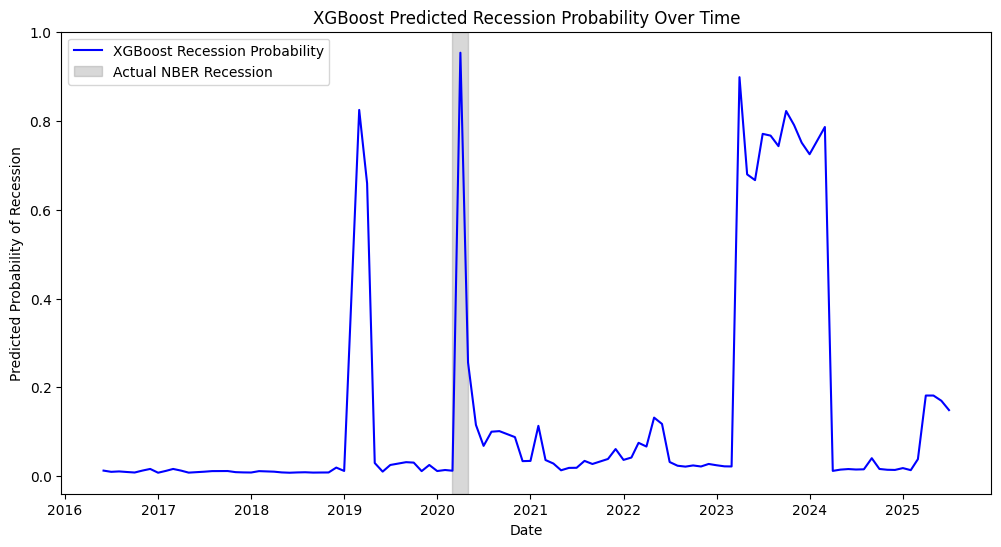

In [20]:
from matplotlib import pyplot as plt

xgb_proba_table = testing_data[['aligned_date']].copy()
xgb_proba_table['y_recession_prob'] = y_recession_probs
xgb_proba_table = pd.merge(
    xgb_proba_table, 
    df_final[['aligned_date', 'recession']], 
    on='aligned_date', 
    how='left'
)
xgb_proba_table['change'] = xgb_proba_table['recession'].diff()
starts = xgb_proba_table[xgb_proba_table['change'] == 1]['aligned_date'].tolist()
ends = xgb_proba_table[xgb_proba_table['change'] == -1]['aligned_date'].tolist()
if xgb_proba_table['recession'].iloc[0] == 1:
    starts.insert(0, xgb_proba_table['aligned_date'].iloc[0])
if xgb_proba_table['recession'].iloc[-1] == 1:
    ends.append(xgb_proba_table['aligned_date'].iloc[-1])
    

plt.figure(figsize=(12, 6))

# 2. Plot the probability line
plt.plot(xgb_proba_table['aligned_date'], xgb_proba_table['y_recession_prob'], 
         label='XGBoost Recession Probability', color='blue')

for s, e in zip(starts, ends):
    plt.axvspan(s, e, color='gray', alpha=0.3, label='Actual NBER Recession')
plt.title('XGBoost Predicted Recession Probability Over Time')
plt.xlabel('Date')
plt.ylabel('Predicted Probability of Recession')
plt.legend()